# MNIST Model Comparison

Goal: Compare Perceptron, Artificial Neural Networks (ANN), and Convolutional Neural Networks (CNN) on the MNIST handwritten digit dataset.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


## 1. Dataset Exploration

In [26]:
df = pd.read_csv(r"C:\Users\ngarg\Downloads\train1.csv")
df.head(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
df.shape

(42000, 785)

In [28]:
df['label'].nunique()

10

In [29]:
df['label'].value_counts()

label
1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: count, dtype: int64

In [30]:
df.isnull().sum()

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [32]:
df.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


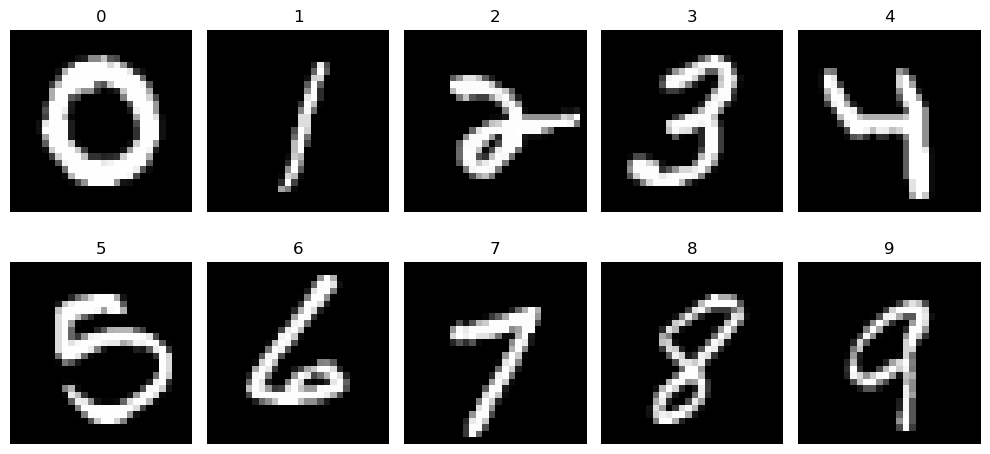

In [33]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

indices = [1, 15, 34, 70, 921, 1081, 998, 961, 1026, 41999]

for ax, idx in zip(axes.ravel(), indices):
    sample = df.iloc[idx]
    label = sample['label']
    image = sample.drop('label').values.reshape(28, 28)

    ax.imshow(image, cmap='grey')
    ax.set_title(f"{label}")
    ax.axis('off')

plt.tight_layout()
plt.show()

## 2. Data Preprocessing

In [34]:
x = df.drop(columns = ['label'])
y = df['label']

In [35]:
x = (x / 254).astype(np.float32)

In [36]:
x.shape

(42000, 784)

## 3. Perceptron

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42 ,stratify=y)

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Dropout

In [39]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),
    Dropout(0.3),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.2),

    Dense(10, activation='softmax')
])

c:\Users\ngarg\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9949 - loss: 0.0171 - val_accuracy: 0.9798 - val_loss: 0.1154
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9942 - loss: 0.0169 - val_accuracy: 0.9748 - val_loss: 0.1339
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9939 - loss: 0.0200 - val_accuracy: 0.9762 - val_loss: 0.1247
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9937 - loss: 0.0194 - val_accuracy: 0.9793 - val_loss: 0.1180
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9949 - loss: 0.0178 - val_accuracy: 0.9782 - val_loss: 0.1137
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9952 - loss: 0.0147 - val_accuracy: 0.9782 - val_loss: 0.1124
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9949 - loss: 0.0160 - val_accuracy: 0.9776 - val_loss: 0.1221
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9952 - loss: 0.0151 - val_accu

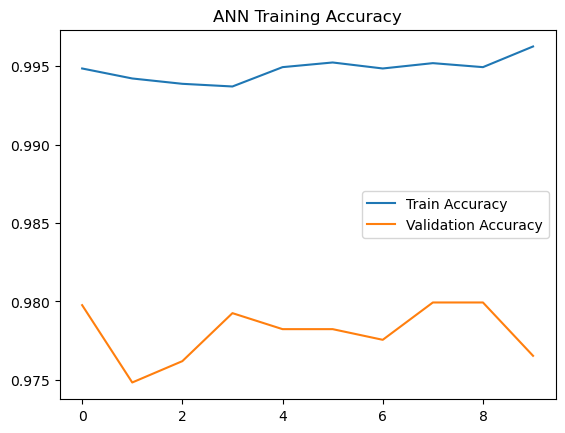

In [53]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("ANN Training Accuracy")
plt.legend()
plt.show()

In [46]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("ANN Test Accuracy:", test_acc)

394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9751 - loss: 0.1431
ANN Test Accuracy: 0.975079357624054


In [ ]:
y_pred = np.argmax(model.predict(X_test), axis=1)

394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [50]:
cm = confusion_matrix(y_test, y_pred)

labels = [0,1,2,3,4,5,6,7,8,9]
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_df.index.name = "Actual"
cm_df.columns.name = "Predicted"
cm_df


Predicted,0,1,2,3,4,5,6,7,8,9
Actual,,,,,,,,,,
0,1222,0,3,1,3,1,4,0,2,4
1,0,1397,5,0,0,0,1,1,1,0
2,1,4,1224,3,3,0,0,14,4,0
3,1,2,11,1253,1,9,0,5,15,8
4,2,3,1,0,1197,0,1,2,3,13
5,5,3,2,11,0,1088,12,1,10,7
6,4,0,0,0,4,4,1225,0,4,0
7,0,3,7,3,2,1,0,1298,0,6
8,3,17,10,2,2,2,2,3,1172,6


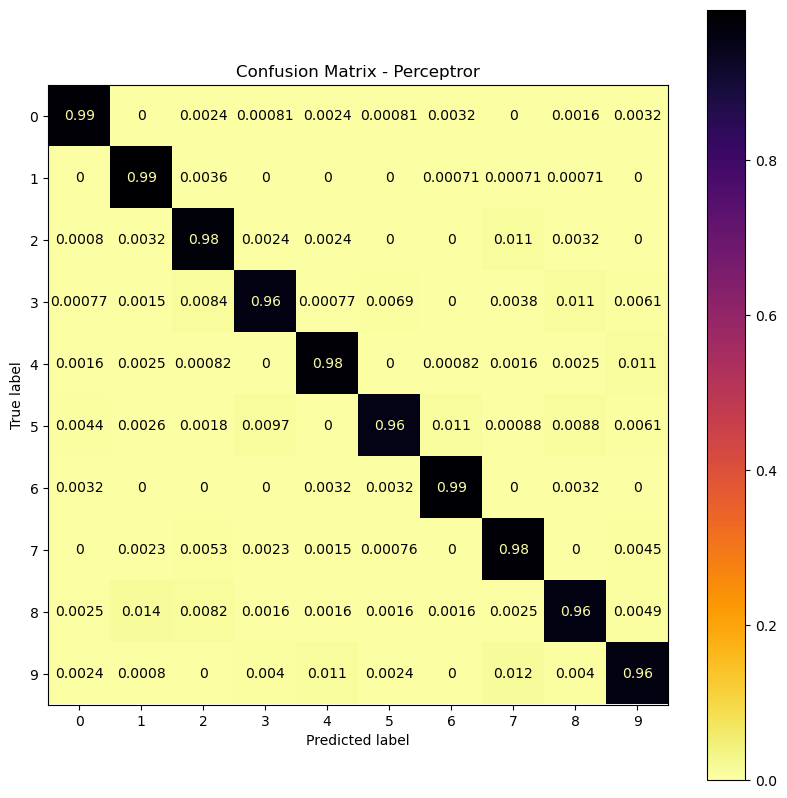

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10,10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="inferno_r",
    normalize="true", 
    ax=ax
)

plt.title("Confusion Matrix - Perceptror")
plt.show()

In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1240
           1       0.98      0.99      0.99      1405
           2       0.97      0.98      0.97      1253
           3       0.98      0.96      0.97      1305
           4       0.98      0.98      0.98      1222
           5       0.98      0.96      0.97      1139
           6       0.98      0.99      0.99      1241
           7       0.97      0.98      0.98      1320
           8       0.96      0.96      0.96      1219
           9       0.96      0.96      0.96      1256

    accuracy                           0.98     12600
   macro avg       0.98      0.97      0.97     12600
weighted avg       0.98      0.98      0.98     12600



# Results and Observation (ANN Model)

## 1. Model Performance

The Artificial Neural Network (ANN) model was trained using a multi-layer perceptron architecture with dropout regularization to improve generalization.

The final model achieved a test accuracy of approximately **0.975 (97.5%)**, while the classification report shows an overall weighted F1-score of approximately **0.97**.

---

## 2. Classification Report Analysis

The classification report shows strong performance across all digit classes.

Most digits such as **0, 1, 4, 6, and 7** achieved very high precision and recall values (above 0.97), indicating excellent classification performance.

However, minor misclassifications are still observed in visually similar digits such as **3, 5, 8, and 9**, where slight overlap in handwritten patterns leads to confusion.

Overall, the macro average F1-score is approximately **0.97**, while the weighted average F1-score is approximately **0.97**, indicating strong and balanced performance across all classes.

---

## 3. Confusion Matrix Analysis

The confusion matrix confirms that the ANN model performs significantly better than the Perceptron model.

- Most digits (0, 1, 4, 6, 7) are classified with very high accuracy.
- Digit 8 and 9 show minor confusion with similar-shaped digits.
- Misclassifications are minimal and mostly occur between visually similar digits.

This indicates that the ANN successfully learns non-linear relationships in the dataset, improving class separation.

---

## 4. Final Observation

The ANN model significantly improves performance over the Perceptron model by learning complex non-linear patterns in handwritten digits.

The use of hidden layers and dropout regularization helps in achieving high accuracy while reducing overfitting.

Overall, ANN demonstrates strong generalization ability and is well-suited for image classification tasks like MNIST.

---

## 5. Code Output Summary

- Best Model Accuracy: **0.9751 (97.51%)**
- Training Accuracy: ~99.6%
- Validation Accuracy: ~97–98%
- Weighted F1-score: ~0.97